## Check Mixed Data

🔍 Loading mixed dataset...
✅ Dataset loaded successfully!
📊 Dataset shape: 1,000 rows × 5 columns
💾 Memory usage: 1.18 MB

📋 DATASET OVERVIEW
Dataset dimensions: (1000, 5)
Columns: ['body', 'label', 'source', 'subject', 'synthetic']

⚠️  Missing values found:
  subject: 2 (0.2%)

📊 Data types:
  object: 3 columns
  int64: 2 columns

🤖 SYNTHETIC vs REAL-WORLD DATA DISTRIBUTION
📊 Data Source Distribution:
  Real-world data (synthetic=0): 500 samples (50.0%)
  Synthetic data (synthetic=1):  500 samples (50.0%)
  Total samples: 1,000

🏷️  LABEL DISTRIBUTION ANALYSIS
✅ Using label column: 'label'

📊 Overall Label Distribution:
  Benign (label=0): 375 samples (37.5%)
  Malicious (label=1): 625 samples (62.5%)

📊 DETAILED CROSS-TABULATION ANALYSIS
📋 Raw Counts:
label        0    1   All
synthetic                
0          243  257   500
1          132  368   500
All        375  625  1000

📋 Percentage Distribution (by data source):
label         0     1
synthetic            
0          48.6 

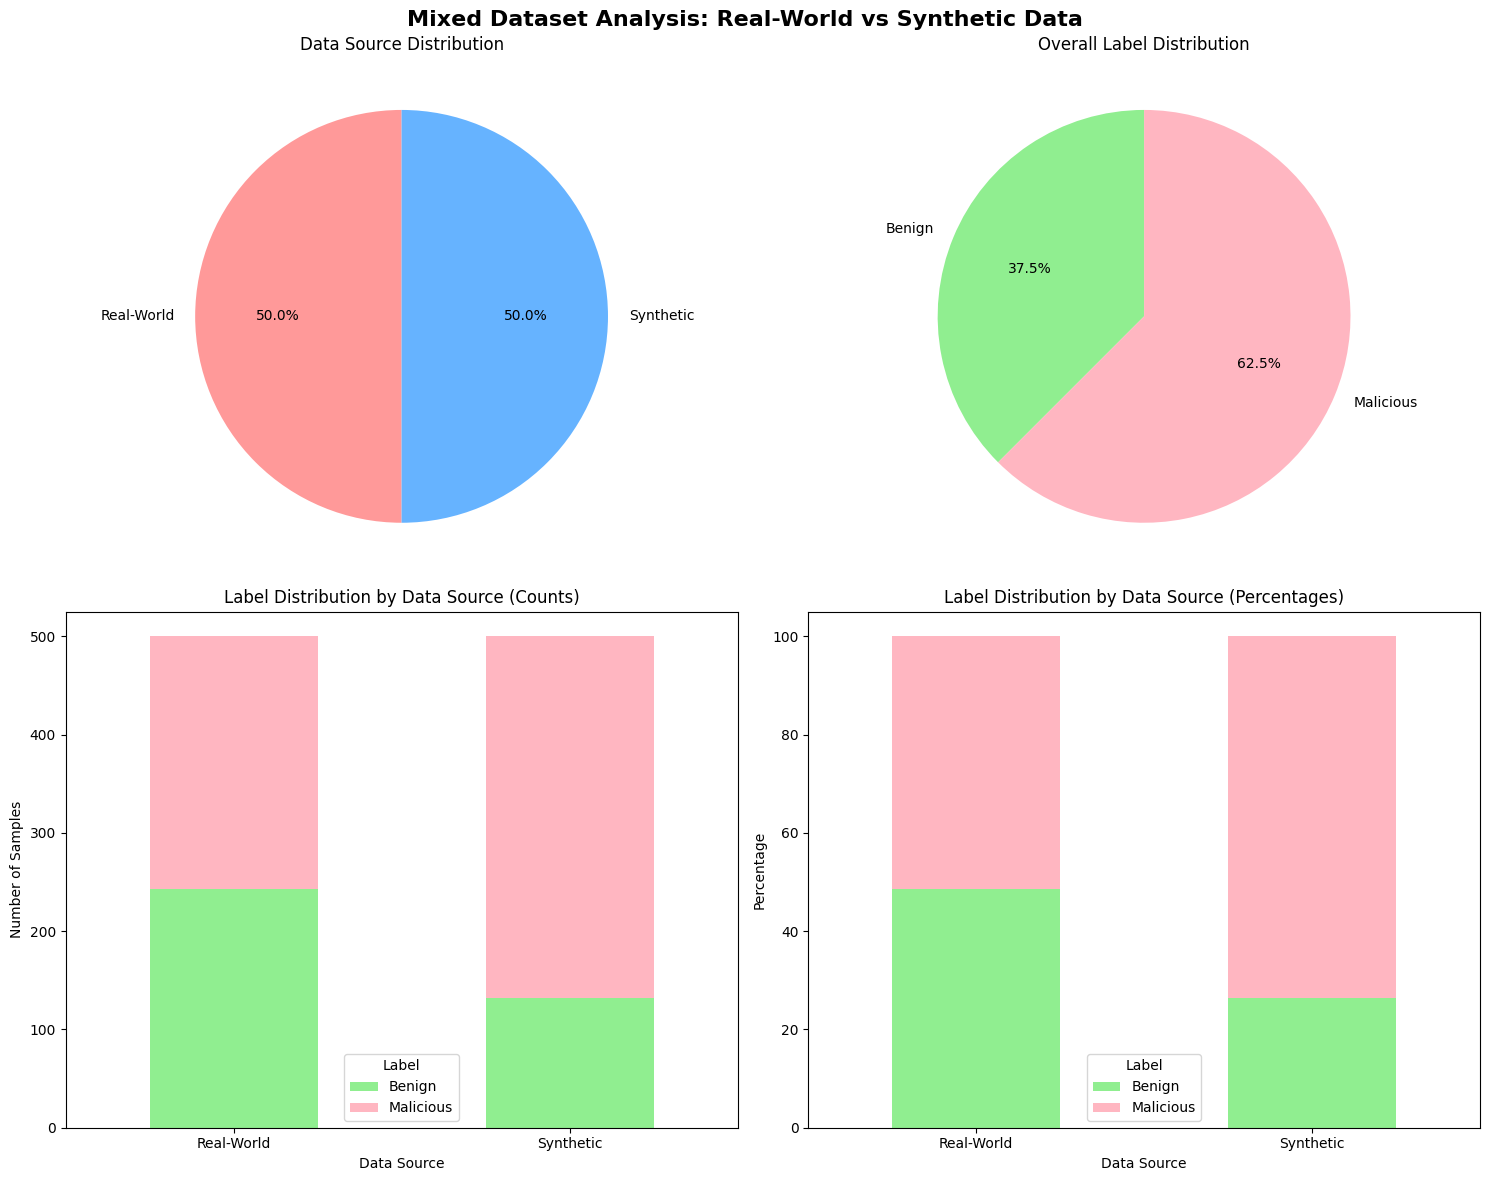

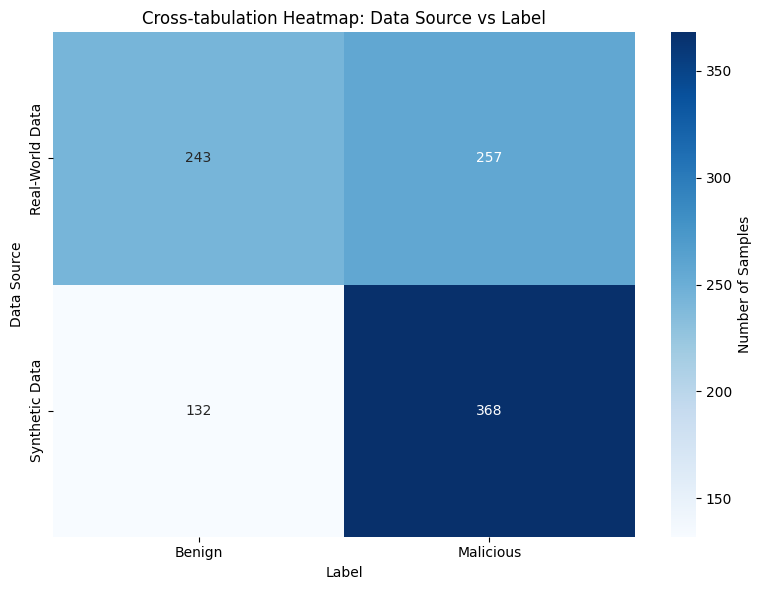


📊 SUMMARY STATISTICS TABLE
   Dataset Total Samples Benign Count Benign % Malicious Count Malicious %
   Overall         1,000          375    37.5%             625       62.5%
Real-World           500          243    48.6%             257       51.4%
 Synthetic           500          132    26.4%             368       73.6%

💡 KEY INSIGHTS
🎯 Class Imbalance Ratios (Malicious:Benign):
  Overall dataset: 1:0.60 (malicious ratio: 62.5%)
  Real-world data: 1:0.95 (malicious ratio: 51.4%)
  Synthetic data:  1:0.36 (malicious ratio: 73.6%)

📈 Data Augmentation Impact:
  Real-world samples represent 50.0% of the mixed dataset
  Synthetic samples provide 50.0% augmentation
  Data amplification factor: 1.0x

🔍 Quality Checks:
  ✅ Sample counts verified: 500 + 500 = 1,000
  ✅ Binary classification labels confirmed: [np.int64(0), np.int64(1)]
  📊 Dataset balance assessment: Moderately imbalanced (ratio: 0.60)

✅ Analysis completed successfully!
📁 Dataset: ..\data\mixed\mixed_five_email_phishing

In [1]:
# Mixed Dataset Statistics Analysis
# Analyze the distribution of labels between real-world and synthetic data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# ==============================================================================
# 1. LOAD AND EXAMINE THE DATASET
# ==============================================================================

# Define the path to your mixed dataset
# data_path = Path("../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv")
data_path = Path("../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_500+500.csv")


# Load the dataset
print("🔍 Loading mixed dataset...")
df = pd.read_csv(data_path)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ==============================================================================
# 2. BASIC DATASET OVERVIEW
# ==============================================================================

print("\n" + "="*60)
print("📋 DATASET OVERVIEW")
print("="*60)

# Display basic info
print(f"Dataset dimensions: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Check for missing values
missing_stats = df.isnull().sum()
if missing_stats.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    for col, missing_count in missing_stats[missing_stats > 0].items():
        print(f"  {col}: {missing_count:,} ({missing_count/len(df)*100:.1f}%)")
else:
    print(f"\n✅ No missing values found")

# Data types
print(f"\n📊 Data types:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"  {dtype}: {count} columns")

# ==============================================================================
# 3. SYNTHETIC COLUMN ANALYSIS
# ==============================================================================

print("\n" + "="*60)
print("🤖 SYNTHETIC vs REAL-WORLD DATA DISTRIBUTION")
print("="*60)

# Verify synthetic column exists
if 'synthetic' not in df.columns:
    print("❌ ERROR: 'synthetic' column not found in dataset!")
    print(f"Available columns: {list(df.columns)}")
else:
    # Synthetic column distribution
    synthetic_counts = df['synthetic'].value_counts().sort_index()
    synthetic_pct = df['synthetic'].value_counts(normalize=True).sort_index() * 100
    
    print("📊 Data Source Distribution:")
    print(f"  Real-world data (synthetic=0): {synthetic_counts[0]:,} samples ({synthetic_pct[0]:.1f}%)")
    print(f"  Synthetic data (synthetic=1):  {synthetic_counts[1]:,} samples ({synthetic_pct[1]:.1f}%)")
    print(f"  Total samples: {len(df):,}")

# ==============================================================================
# 4. LABEL COLUMN ANALYSIS
# ==============================================================================

print("\n" + "="*60)
print("🏷️  LABEL DISTRIBUTION ANALYSIS")
print("="*60)

# Find the label column
label_column = None
potential_label_cols = ['label', 'Label', 'is_attack', 'target', 'class', 'y']

for col in potential_label_cols:
    if col in df.columns:
        label_column = col
        break

if label_column is None:
    print("❌ ERROR: Label column not found!")
    print(f"Available columns: {list(df.columns)}")
    print("Please specify the correct label column name.")
else:
    print(f"✅ Using label column: '{label_column}'")
    
    # Overall label distribution
    label_counts = df[label_column].value_counts().sort_index()
    label_pct = df[label_column].value_counts(normalize=True).sort_index() * 100
    
    print(f"\n📊 Overall Label Distribution:")
    for label_value, count in label_counts.items():
        label_type = "Benign" if label_value == 0 else "Malicious" if label_value == 1 else f"Class {label_value}"
        pct = label_pct[label_value]
        print(f"  {label_type} ({label_column}={label_value}): {count:,} samples ({pct:.1f}%)")

# ==============================================================================
# 5. CROSS-TABULATION ANALYSIS
# ==============================================================================

if 'synthetic' in df.columns and label_column is not None:
    print("\n" + "="*60)
    print("📊 DETAILED CROSS-TABULATION ANALYSIS")
    print("="*60)
    
    # Create cross-tabulation
    crosstab = pd.crosstab(df['synthetic'], df[label_column], margins=True)
    crosstab_pct = pd.crosstab(df['synthetic'], df[label_column], normalize='index') * 100
    
    print("📋 Raw Counts:")
    print(crosstab)
    
    print(f"\n📋 Percentage Distribution (by data source):")
    print(crosstab_pct.round(1))
    
    # Detailed breakdown
    print(f"\n🔍 DETAILED BREAKDOWN:")
    print(f"{'='*50}")
    
    # Real-world data analysis
    real_data = df[df['synthetic'] == 0]
    print(f"📊 REAL-WORLD DATA (synthetic=0):")
    print(f"  Total samples: {len(real_data):,}")
    
    if len(real_data) > 0:
        real_labels = real_data[label_column].value_counts().sort_index()
        real_labels_pct = real_data[label_column].value_counts(normalize=True).sort_index() * 100
        
        for label_value, count in real_labels.items():
            label_type = "Benign" if label_value == 0 else "Malicious" if label_value == 1 else f"Class {label_value}"
            pct = real_labels_pct[label_value]
            pct_of_total = (count / len(df)) * 100
            print(f"    {label_type}: {count:,} samples ({pct:.1f}% of real data, {pct_of_total:.1f}% of total)")
    
    print(f"\n🤖 SYNTHETIC DATA (synthetic=1):")
    synthetic_data = df[df['synthetic'] == 1]
    print(f"  Total samples: {len(synthetic_data):,}")
    
    if len(synthetic_data) > 0:
        synth_labels = synthetic_data[label_column].value_counts().sort_index()
        synth_labels_pct = synthetic_data[label_column].value_counts(normalize=True).sort_index() * 100
        
        for label_value, count in synth_labels.items():
            label_type = "Benign" if label_value == 0 else "Malicious" if label_value == 1 else f"Class {label_value}"
            pct = synth_labels_pct[label_value]
            pct_of_total = (count / len(df)) * 100
            print(f"    {label_type}: {count:,} samples ({pct:.1f}% of synthetic data, {pct_of_total:.1f}% of total)")

# ==============================================================================
# 6. VISUAL ANALYSIS
# ==============================================================================

if 'synthetic' in df.columns and label_column is not None:
    print(f"\n📈 CREATING VISUALIZATIONS...")
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Mixed Dataset Analysis: Real-World vs Synthetic Data', fontsize=16, fontweight='bold')
    
    # 1. Overall data source distribution (pie chart)
    ax1 = axes[0, 0]
    synthetic_counts = df['synthetic'].value_counts().sort_index()
    labels = ['Real-World', 'Synthetic']
    colors = ['#ff9999', '#66b3ff']
    
    wedges, texts, autotexts = ax1.pie(synthetic_counts.values, labels=labels, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax1.set_title('Data Source Distribution')
    
    # 2. Overall label distribution (pie chart)
    ax2 = axes[0, 1]
    label_counts = df[label_column].value_counts().sort_index()
    label_names = ['Benign' if x == 0 else 'Malicious' if x == 1 else f'Class {x}' for x in label_counts.index]
    colors_labels = ['#90EE90', '#FFB6C1']  # Light green for benign, light red for malicious
    
    wedges, texts, autotexts = ax2.pie(label_counts.values, labels=label_names, autopct='%1.1f%%', 
                                      colors=colors_labels, startangle=90)
    ax2.set_title(f'Overall {label_column.title()} Distribution')
    
    # 3. Stacked bar chart showing label distribution by data source
    ax3 = axes[1, 0]
    crosstab_for_plot = pd.crosstab(df['synthetic'], df[label_column])
    
    # Rename index and columns for better display
    crosstab_for_plot.index = ['Real-World', 'Synthetic']
    crosstab_for_plot.columns = ['Benign' if x == 0 else 'Malicious' if x == 1 else f'Class {x}' 
                                for x in crosstab_for_plot.columns]
    
    crosstab_for_plot.plot(kind='bar', stacked=True, ax=ax3, color=['#90EE90', '#FFB6C1'])
    ax3.set_title('Label Distribution by Data Source (Counts)')
    ax3.set_xlabel('Data Source')
    ax3.set_ylabel('Number of Samples')
    ax3.legend(title='Label')
    ax3.tick_params(axis='x', rotation=0)
    
    # 4. Percentage stacked bar chart
    ax4 = axes[1, 1]
    crosstab_pct_plot = pd.crosstab(df['synthetic'], df[label_column], normalize='index') * 100
    crosstab_pct_plot.index = ['Real-World', 'Synthetic']
    crosstab_pct_plot.columns = ['Benign' if x == 0 else 'Malicious' if x == 1 else f'Class {x}' 
                                for x in crosstab_pct_plot.columns]
    
    crosstab_pct_plot.plot(kind='bar', stacked=True, ax=ax4, color=['#90EE90', '#FFB6C1'])
    ax4.set_title('Label Distribution by Data Source (Percentages)')
    ax4.set_xlabel('Data Source')
    ax4.set_ylabel('Percentage')
    ax4.legend(title='Label')
    ax4.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Additional heatmap for detailed view
    plt.figure(figsize=(8, 6))
    crosstab_for_heatmap = pd.crosstab(df['synthetic'], df[label_column])
    crosstab_for_heatmap.index = ['Real-World Data', 'Synthetic Data']
    crosstab_for_heatmap.columns = ['Benign' if x == 0 else 'Malicious' if x == 1 else f'Class {x}' 
                                   for x in crosstab_for_heatmap.columns]
    
    sns.heatmap(crosstab_for_heatmap, annot=True, fmt='d', cmap='Blues', 
                cbar_kws={'label': 'Number of Samples'})
    plt.title('Cross-tabulation Heatmap: Data Source vs Label')
    plt.ylabel('Data Source')
    plt.xlabel('Label')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 7. SUMMARY STATISTICS TABLE
# ==============================================================================

if 'synthetic' in df.columns and label_column is not None:
    print("\n" + "="*60)
    print("📊 SUMMARY STATISTICS TABLE")
    print("="*60)
    
    # Create comprehensive summary table
    summary_data = []
    
    # Overall statistics
    total_samples = len(df)
    total_benign = len(df[df[label_column] == 0])
    total_malicious = len(df[df[label_column] == 1])
    
    summary_data.append({
        'Dataset': 'Overall',
        'Total Samples': f"{total_samples:,}",
        'Benign Count': f"{total_benign:,}",
        'Benign %': f"{(total_benign/total_samples)*100:.1f}%",
        'Malicious Count': f"{total_malicious:,}",
        'Malicious %': f"{(total_malicious/total_samples)*100:.1f}%"
    })
    
    # Real-world data statistics
    real_data = df[df['synthetic'] == 0]
    real_total = len(real_data)
    real_benign = len(real_data[real_data[label_column] == 0])
    real_malicious = len(real_data[real_data[label_column] == 1])
    
    summary_data.append({
        'Dataset': 'Real-World',
        'Total Samples': f"{real_total:,}",
        'Benign Count': f"{real_benign:,}",
        'Benign %': f"{(real_benign/real_total)*100:.1f}%" if real_total > 0 else "0.0%",
        'Malicious Count': f"{real_malicious:,}",
        'Malicious %': f"{(real_malicious/real_total)*100:.1f}%" if real_total > 0 else "0.0%"
    })
    
    # Synthetic data statistics
    synth_data = df[df['synthetic'] == 1]
    synth_total = len(synth_data)
    synth_benign = len(synth_data[synth_data[label_column] == 0])
    synth_malicious = len(synth_data[synth_data[label_column] == 1])
    
    summary_data.append({
        'Dataset': 'Synthetic',
        'Total Samples': f"{synth_total:,}",
        'Benign Count': f"{synth_benign:,}",
        'Benign %': f"{(synth_benign/synth_total)*100:.1f}%" if synth_total > 0 else "0.0%",
        'Malicious Count': f"{synth_malicious:,}",
        'Malicious %': f"{(synth_malicious/synth_total)*100:.1f}%" if synth_total > 0 else "0.0%"
    })
    
    # Create and display summary DataFrame
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# ==============================================================================
# 8. ADDITIONAL INSIGHTS
# ==============================================================================

if 'synthetic' in df.columns and label_column is not None:
    print("\n" + "="*60)
    print("💡 KEY INSIGHTS")
    print("="*60)
    
    # Calculate class imbalance ratios
    overall_imbalance = total_malicious / total_benign if total_benign > 0 else float('inf')
    real_imbalance = real_malicious / real_benign if real_benign > 0 else float('inf')
    synth_imbalance = synth_malicious / synth_benign if synth_benign > 0 else float('inf')
    
    print(f"🎯 Class Imbalance Ratios (Malicious:Benign):")
    print(f"  Overall dataset: 1:{1/overall_imbalance:.2f} (malicious ratio: {(total_malicious/total_samples)*100:.1f}%)")
    print(f"  Real-world data: 1:{1/real_imbalance:.2f} (malicious ratio: {(real_malicious/real_total)*100:.1f}%)" if real_total > 0 else "  Real-world data: No data")
    print(f"  Synthetic data:  1:{1/synth_imbalance:.2f} (malicious ratio: {(synth_malicious/synth_total)*100:.1f}%)" if synth_total > 0 else "  Synthetic data: No data")
    
    print(f"\n📈 Data Augmentation Impact:")
    print(f"  Real-world samples represent {(real_total/total_samples)*100:.1f}% of the mixed dataset")
    print(f"  Synthetic samples provide {(synth_total/total_samples)*100:.1f}% augmentation")
    
    if real_total > 0 and synth_total > 0:
        print(f"  Data amplification factor: {synth_total/real_total:.1f}x")
    
    print(f"\n🔍 Quality Checks:")
    
    # Check for potential data quality issues
    if total_samples != real_total + synth_total:
        print(f"  ⚠️  Warning: Sample count mismatch detected!")
    else:
        print(f"  ✅ Sample counts verified: {real_total:,} + {synth_total:,} = {total_samples:,}")
    
    # Check label consistency
    unique_labels = sorted(df[label_column].unique())
    if set(unique_labels) == {0, 1}:
        print(f"  ✅ Binary classification labels confirmed: {unique_labels}")
    else:
        print(f"  ℹ️  Multi-class or non-standard labels detected: {unique_labels}")
    
    # Dataset balance assessment
    overall_balance = min(total_benign, total_malicious) / max(total_benign, total_malicious)
    if overall_balance >= 0.8:
        balance_status = "Well-balanced"
    elif overall_balance >= 0.5:
        balance_status = "Moderately imbalanced"
    else:
        balance_status = "Highly imbalanced"
    
    print(f"  📊 Dataset balance assessment: {balance_status} (ratio: {overall_balance:.2f})")

print(f"\n✅ Analysis completed successfully!")
print(f"📁 Dataset: {data_path}")
print(f"🕒 Analysis timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

## Portion Analysis

🔬 GENERATING CYBERSECURITY RESEARCH SCENARIOS
Generated 18 experimental scenarios

📊 EXPERIMENTAL SCENARIOS - COMPREHENSIVE FOCUS
target_synthetic_pct target_malicious_ratio  total_samples actual_synthetic_pct malicious_in_synthetic_pct attack_augmentation_factor overall_attack_rate class_imbalance_ratio
                0.0%                   0.30            100                 0.0%                       0.0%                       0.00               55.0%                  1.22
                0.0%                   0.50            100                 0.0%                       0.0%                       0.00               55.0%                  1.22
                0.0%                   0.70            100                 0.0%                       0.0%                       0.00               55.0%                  1.22
               10.0%                   0.30            111                 9.9%                      27.3%                       0.05               52.3%             

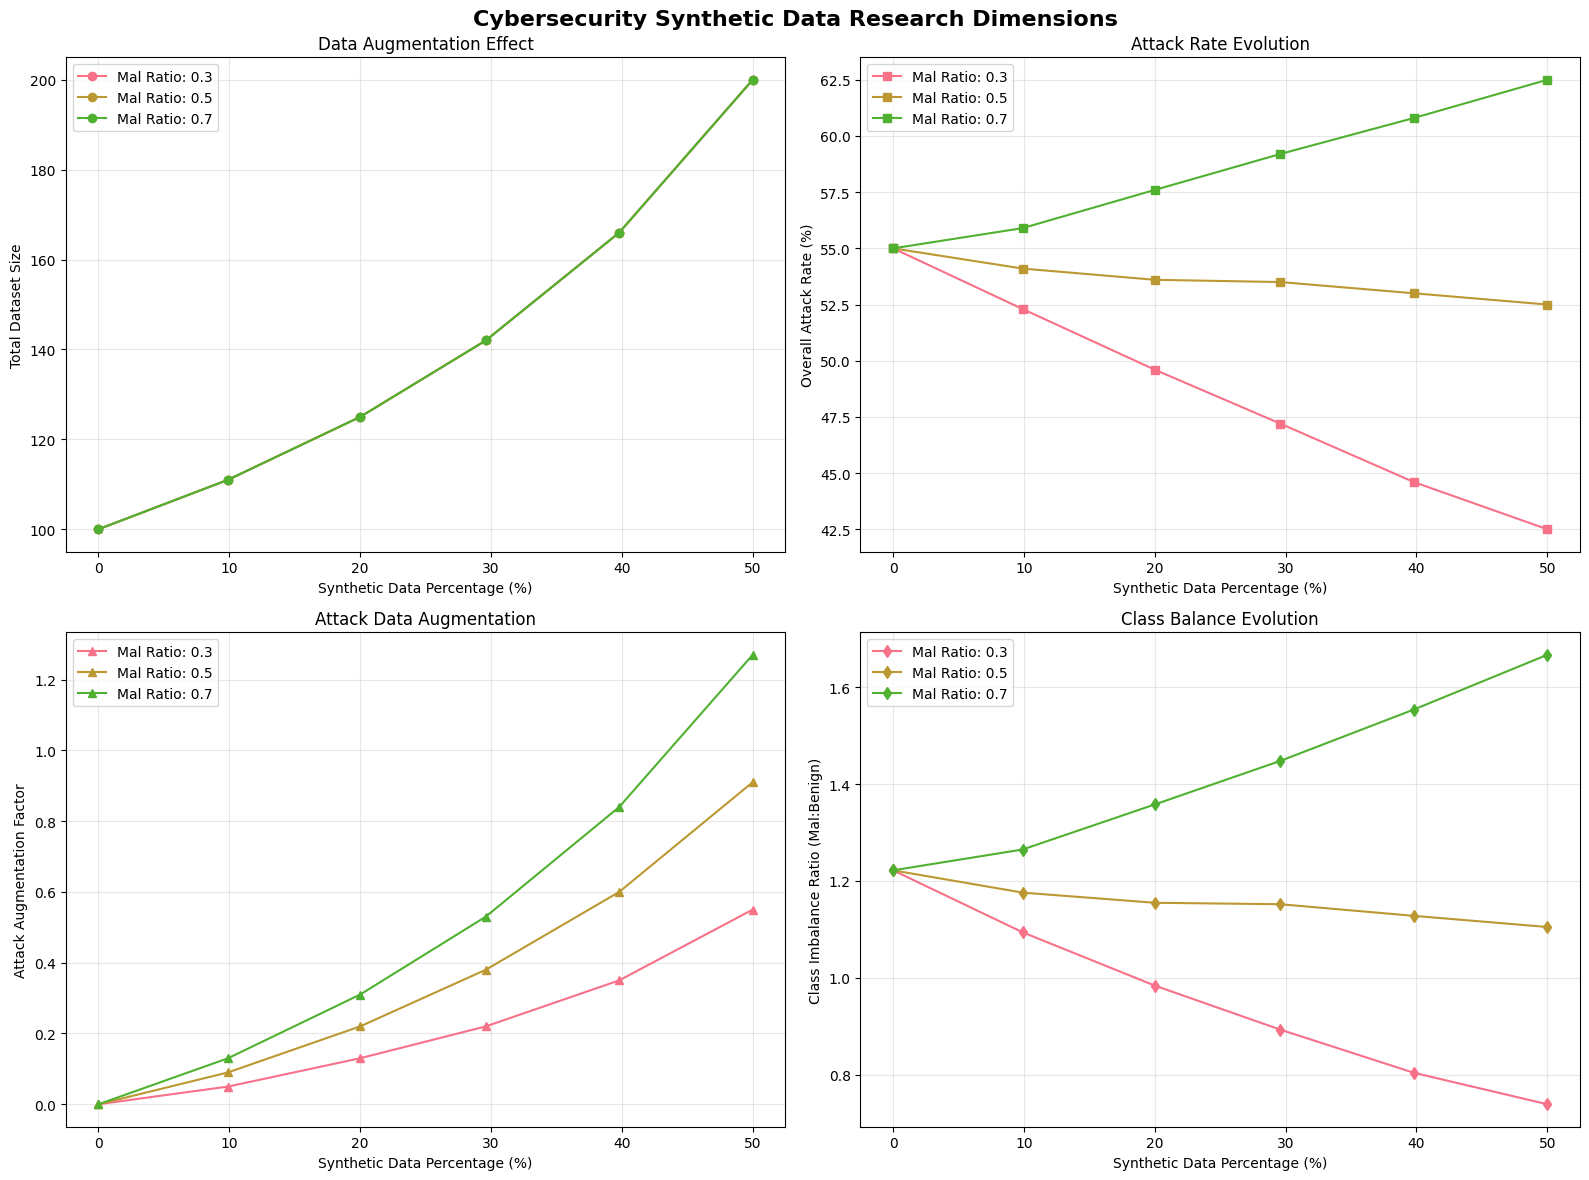

In [2]:
# Cybersecurity Synthetic Data Portion Framework
# Multi-dimensional approach for studying synthetic data impact

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

class CybersecurityPortionFramework:
    """
    Framework for systematically studying synthetic data portions in cybersecurity ML research.
    
    Supports multiple research dimensions:
    1. Overall synthetic data ratio (data augmentation study)
    2. Synthetic malicious data ratio (class imbalance study) 
    3. Attack augmentation factor (rare event study)
    """
    
    def __init__(self):
        self.scenarios = []
        
    def generate_scenarios(self, base_real_benign=45, base_real_malicious=55, 
                          synthetic_portions=[0, 10, 20, 30, 40, 50],
                          malicious_ratios=[0.3, 0.5, 0.7]):
        """
        Generate experimental scenarios for cybersecurity research.
        
        Args:
            base_real_benign (int): Base number of real benign samples
            base_real_malicious (int): Base number of real malicious samples  
            synthetic_portions (list): Synthetic data percentages to study (0-50%)
            malicious_ratios (list): Ratios of malicious samples in synthetic data
        """
        
        scenarios = []
        
        for synth_pct in synthetic_portions:
            for mal_ratio in malicious_ratios:
                scenario = self._calculate_scenario(
                    base_real_benign, base_real_malicious, synth_pct, mal_ratio
                )
                scenarios.append(scenario)
        
        self.scenarios = pd.DataFrame(scenarios)
        return self.scenarios
    
    def _calculate_scenario(self, real_benign, real_malicious, synth_pct, mal_ratio):
        """Calculate a single experimental scenario."""
        
        total_real = real_benign + real_malicious
        
        if synth_pct == 0:
            # No synthetic data
            synth_total = 0
            synth_malicious = 0
            synth_benign = 0
        else:
            # Calculate synthetic samples needed for target percentage
            synth_total = int(total_real * synth_pct / (100 - synth_pct))
            synth_malicious = int(synth_total * mal_ratio)
            synth_benign = synth_total - synth_malicious
        
        total_samples = total_real + synth_total
        total_malicious = real_malicious + synth_malicious
        total_benign = real_benign + synth_benign
        
        # Calculate research metrics
        overall_synthetic_pct = (synth_total / total_samples * 100) if total_samples > 0 else 0
        malicious_synthetic_pct = (synth_malicious / synth_total * 100) if synth_total > 0 else 0
        attack_augmentation_factor = (synth_malicious / real_malicious) if real_malicious > 0 else 0
        overall_attack_rate = (total_malicious / total_samples * 100) if total_samples > 0 else 0
        
        return {
            # Input parameters
            'target_synthetic_pct': synth_pct,
            'target_malicious_ratio': mal_ratio,
            
            # Raw counts
            'real_benign': real_benign,
            'real_malicious': real_malicious,
            'synth_benign': synth_benign,
            'synth_malicious': synth_malicious,
            'total_real': total_real,
            'total_synthetic': synth_total,
            'total_samples': total_samples,
            'total_benign': total_benign,
            'total_malicious': total_malicious,
            
            # Research metrics
            'actual_synthetic_pct': round(overall_synthetic_pct, 1),
            'malicious_in_synthetic_pct': round(malicious_synthetic_pct, 1),
            'attack_augmentation_factor': round(attack_augmentation_factor, 2),
            'overall_attack_rate': round(overall_attack_rate, 1),
            'class_imbalance_ratio': round(total_malicious / total_benign, 3) if total_benign > 0 else float('inf')
        }
    
    def display_scenarios(self, research_focus="comprehensive"):
        """
        Display scenarios formatted for different research focuses.
        
        Args:
            research_focus (str): 'comprehensive', 'augmentation', 'imbalance', or 'attack_focus'
        """
        
        if self.scenarios.empty:
            print("No scenarios generated. Call generate_scenarios() first.")
            return
        
        if research_focus == "comprehensive":
            # Show all key metrics
            display_cols = [
                'target_synthetic_pct', 'target_malicious_ratio', 'total_samples',
                'actual_synthetic_pct', 'malicious_in_synthetic_pct', 
                'attack_augmentation_factor', 'overall_attack_rate', 'class_imbalance_ratio'
            ]
            
        elif research_focus == "augmentation":
            # Focus on data augmentation impact
            display_cols = [
                'target_synthetic_pct', 'total_real', 'total_synthetic', 'total_samples',
                'actual_synthetic_pct', 'overall_attack_rate'
            ]
            
        elif research_focus == "imbalance":
            # Focus on class imbalance
            display_cols = [
                'target_synthetic_pct', 'target_malicious_ratio', 'total_benign', 'total_malicious',
                'overall_attack_rate', 'class_imbalance_ratio'
            ]
            
        elif research_focus == "attack_focus":
            # Focus on attack data augmentation
            display_cols = [
                'target_synthetic_pct', 'real_malicious', 'synth_malicious', 'total_malicious',
                'attack_augmentation_factor', 'overall_attack_rate'
            ]
        
        print(f"\n📊 EXPERIMENTAL SCENARIOS - {research_focus.upper()} FOCUS")
        print("="*80)
        
        display_df = self.scenarios[display_cols].copy()
        
        # Format for better readability
        for col in display_df.columns:
            if 'pct' in col or 'rate' in col:
                display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}%")
            elif 'ratio' in col or 'factor' in col:
                display_df[col] = display_df[col].apply(lambda x: f"{x:.2f}")
        
        print(display_df.to_string(index=False))
        
    def plot_research_dimensions(self):
        """Create visualizations for different research dimensions."""
        
        if self.scenarios.empty:
            print("No scenarios to plot. Call generate_scenarios() first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Cybersecurity Synthetic Data Research Dimensions', fontsize=16, fontweight='bold')
        
        # 1. Synthetic Data Augmentation Effect
        ax1 = axes[0, 0]
        for mal_ratio in self.scenarios['target_malicious_ratio'].unique():
            subset = self.scenarios[self.scenarios['target_malicious_ratio'] == mal_ratio]
            ax1.plot(subset['actual_synthetic_pct'], subset['total_samples'], 
                    marker='o', label=f'Mal Ratio: {mal_ratio:.1f}')
        
        ax1.set_xlabel('Synthetic Data Percentage (%)')
        ax1.set_ylabel('Total Dataset Size')
        ax1.set_title('Data Augmentation Effect')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Attack Rate Evolution
        ax2 = axes[0, 1]
        for mal_ratio in self.scenarios['target_malicious_ratio'].unique():
            subset = self.scenarios[self.scenarios['target_malicious_ratio'] == mal_ratio]
            ax2.plot(subset['actual_synthetic_pct'], subset['overall_attack_rate'], 
                    marker='s', label=f'Mal Ratio: {mal_ratio:.1f}')
        
        ax2.set_xlabel('Synthetic Data Percentage (%)')
        ax2.set_ylabel('Overall Attack Rate (%)')
        ax2.set_title('Attack Rate Evolution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. Attack Augmentation Factor
        ax3 = axes[1, 0]
        for mal_ratio in self.scenarios['target_malicious_ratio'].unique():
            subset = self.scenarios[self.scenarios['target_malicious_ratio'] == mal_ratio]
            ax3.plot(subset['actual_synthetic_pct'], subset['attack_augmentation_factor'], 
                    marker='^', label=f'Mal Ratio: {mal_ratio:.1f}')
        
        ax3.set_xlabel('Synthetic Data Percentage (%)')
        ax3.set_ylabel('Attack Augmentation Factor')
        ax3.set_title('Attack Data Augmentation')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # 4. Class Imbalance Evolution
        ax4 = axes[1, 1]
        for mal_ratio in self.scenarios['target_malicious_ratio'].unique():
            subset = self.scenarios[self.scenarios['target_malicious_ratio'] == mal_ratio]
            ax4.plot(subset['actual_synthetic_pct'], subset['class_imbalance_ratio'], 
                    marker='d', label=f'Mal Ratio: {mal_ratio:.1f}')
        
        ax4.set_xlabel('Synthetic Data Percentage (%)')
        ax4.set_ylabel('Class Imbalance Ratio (Mal:Benign)')
        ax4.set_title('Class Balance Evolution')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def recommend_scenarios_for_research_question(self, research_question):
        """
        Recommend specific scenarios based on research question.
        
        Args:
            research_question (str): Type of research question
        """
        
        recommendations = {
            "data_augmentation": {
                "description": "How does synthetic data augmentation affect model performance?",
                "key_metric": "actual_synthetic_pct",
                "recommended_focus": "Keep malicious ratio constant, vary synthetic percentage",
                "suggested_config": "malicious_ratio=0.5, synthetic_pct=[0,10,20,30,40,50]"
            },
            
            "class_imbalance": {
                "description": "How does synthetic data help with class imbalance in cybersecurity?",
                "key_metric": "class_imbalance_ratio",
                "recommended_focus": "Vary malicious ratio in synthetic data",
                "suggested_config": "synthetic_pct=30, malicious_ratio=[0.3,0.5,0.7,0.9]"
            },
            
            "attack_detection": {
                "description": "How does synthetic attack data improve rare event detection?",
                "key_metric": "attack_augmentation_factor",
                "recommended_focus": "Maximize synthetic malicious samples",
                "suggested_config": "malicious_ratio=0.8, synthetic_pct=[10,20,30,40,50]"
            },
            
            "model_robustness": {
                "description": "How robust are models to synthetic data quality?",
                "key_metric": "multiple",
                "recommended_focus": "Test multiple configurations systematically",
                "suggested_config": "Full factorial design across all dimensions"
            }
        }
        
        if research_question in recommendations:
            rec = recommendations[research_question]
            print(f"\n🎯 RESEARCH QUESTION: {rec['description']}")
            print(f"📊 Key Metric: {rec['key_metric']}")
            print(f"🔍 Recommended Focus: {rec['recommended_focus']}")
            print(f"⚙️  Suggested Configuration: {rec['suggested_config']}")
        else:
            print(f"Available research questions: {list(recommendations.keys())}")

# Example usage
if __name__ == "__main__":
    # Initialize framework
    framework = CybersecurityPortionFramework()
    
    # Generate scenarios based on your current dataset
    print("🔬 GENERATING CYBERSECURITY RESEARCH SCENARIOS")
    print("="*60)
    
    # Based on your mixed dataset: assume 45 real benign, 55 real malicious
    scenarios = framework.generate_scenarios(
        base_real_benign=45,
        base_real_malicious=55,
        synthetic_portions=[0, 10, 20, 30, 40, 50],  # 0% to 50%, 10% steps
        malicious_ratios=[0.3, 0.5, 0.7]  # Different attack rates in synthetic data
    )
    
    print(f"Generated {len(scenarios)} experimental scenarios")
    
    # Display different research perspectives
    framework.display_scenarios("comprehensive")
    
    # Show research recommendations
    print(f"\n💡 RESEARCH RECOMMENDATIONS")
    print("="*60)
    
    framework.recommend_scenarios_for_research_question("data_augmentation")
    framework.recommend_scenarios_for_research_question("attack_detection")
    
    # Create visualizations
    framework.plot_research_dimensions()